# Start-Page Classifier

Binary classification: **1 = start page ("yes")**, **0 = not start page**.

**Three modalities — 12 models total**

| Modality | Models |
|----------|--------|
| Visual only | KNN+VGG16, XGBoost+VGG16, VGG16 (fine-tuned), EfficientNet-B0 (fine-tuned), LSTM+VGG16 |
| Text only | KNN-BERT, XGBoost-BERT, TEXT-CNN, BERT (fine-tuned) |
| Multimodal | KNN-Ensemble, XGBoost-Ensemble, Early-Fusion BERT+EfficientNet, Late-Fusion BERT+EfficientNet |

**Data**:
- Images: `pdf_pages_png/<dossier>/<dossier>_page_XXXX.png`
- Text: `outputs/page_text_by_page/<dossier>/page/page_XXXX.txt`
- Labels: four annotators (`annotation 1–4.xlsx`)
  - 5 dossiers labelled by all 4 annotators → **majority vote** (≥ 2 of 4 say "yes" = 1)
  - 15 unique dossiers per annotator → single annotator label

## 1. Setup

In [1]:
import sys, os, warnings, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    import os; os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay,
    f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    print('Installing xgboost …')
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

WORKSPACE = Path('/Users/yeqianli/Desktop/data segmentation')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
TEXT_ROOT  = WORKSPACE / 'outputs' / 'page_text_by_page'
BERT_MODEL = 'bert-base-uncased'
NUM_CLASSES = 2

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

Device: cpu


## 2. Load annotations & build labels

In [2]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier'] = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num'] = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num'])
    # normalise start-page label: 'yes' → 1, everything else → 0
    df['label'] = df['Start page'].astype(str).str.strip().str.lower().eq('yes').astype(int)
    return df[['dossier', 'page_num', 'label']]

ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

# dossier sets
dossier_sets = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')

for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique: {len(s - common_dossiers)}')

Common dossiers (5): ['a2478-boer-j-1452187', 'a2478-de-waal-g-l-m-1451034', 'a2478-derksen-a-l-1444766', 'a2478-eijkel-r-1451358', 'a2478-hanssen-g-h-1470445']
Annotation 1: 20 dossiers  |  unique: 15
Annotation 2: 20 dossiers  |  unique: 15
Annotation 3: 20 dossiers  |  unique: 15
Annotation 4: 20 dossiers  |  unique: 15


In [4]:
# ── Majority-vote labels for the 5 shared dossiers ──────────────────────────
shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'label': f'label_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = shared_frames[0].join(shared_frames[1], how='outer')\
                          .join(shared_frames[2], how='outer')\
                          .join(shared_frames[3], how='outer')
label_cols = [f'label_{i}' for i in range(1, 5)]
shared['votes'] = shared[label_cols].sum(axis=1)
# majority: >= 2 out of 4 annotators
shared['label'] = (shared['votes'] >= 2).astype(int)
shared = shared.reset_index()[['dossier', 'page_num', 'label']]
print(f'Shared dossiers pages: {len(shared)}  |  start-pages: {shared["label"].sum()}')

# ── Labels for the 15 unique dossiers per annotator ─────────────────────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)]
    unique_frames.append(sub[['dossier', 'page_num', 'label']])

unique_labels = pd.concat(unique_frames, ignore_index=True)
print(f'Unique dossiers pages: {len(unique_labels)}  |  start-pages: {unique_labels["label"].sum()}')

# ── Final label table ────────────────────────────────────────────────────────
all_labels = pd.concat([shared, unique_labels], ignore_index=True)
all_labels = all_labels.drop_duplicates(subset=['dossier', 'page_num'])
all_labels = all_labels.sort_values(['dossier', 'page_num']).reset_index(drop=True)
print(f'\nTotal pages: {len(all_labels)}  |  start-pages: {all_labels["label"].sum()}  '
      f'({all_labels["label"].mean()*100:.1f}%)')

all_labels.head(8)

Shared dossiers pages: 170  |  start-pages: 123
Unique dossiers pages: 2252  |  start-pages: 1592

Total pages: 2422  |  start-pages: 1715  (70.8%)


,dossier,page_num,label
0,a2478-ambachtsheer-p-1214053,1,1
1,a2478-ambachtsheer-p-1214053,2,1
2,a2478-ambachtsheer-p-1214053,3,0
3,a2478-ambachtsheer-p-1214053,4,1
4,a2478-ambachtsheer-p-1214053,5,0
5,a2478-ambachtsheer-p-1214053,6,1
6,a2478-ambachtsheer-p-1214053,7,1
7,a2478-ambachtsheer-p-1214053,8,0


## 3. Build image & text paths

In [5]:
def page_png_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

all_labels['img_path'] = all_labels.apply(
    lambda r: page_png_path(r['dossier'], r['page_num']), axis=1
)

# keep only rows where the PNG actually exists
exists_mask = all_labels['img_path'].map(lambda p: p.exists())
missing = (~exists_mask).sum()
print(f'Missing PNGs: {missing} / {len(all_labels)}')
all_labels = all_labels[exists_mask].reset_index(drop=True)
print(f'Usable pages: {len(all_labels)}  |  start-pages: {all_labels["label"].sum()}')

all_labels.head(5)
def page_text_path(dossier: str, page_num: int) -> Path:
    return TEXT_ROOT / dossier / 'page' / f'page_{int(page_num):04d}.txt'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

all_labels['text_path'] = all_labels.apply(
    lambda r: page_text_path(r['dossier'], r['page_num']), axis=1
)


Missing PNGs: 0 / 2422
Usable pages: 2422  |  start-pages: 1715


## 4. Train / Validation / Test split

Split is performed **at the dossier level** to avoid leakage (all pages of a dossier
stay in the same split).

In [6]:
dossiers_all = all_labels['dossier'].unique()

train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,   test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

all_labels['split'] = all_labels['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = all_labels[all_labels['split'] == s]
    print(f'{s:6s}: {len(sub):4d} pages  |  start-pages: {sub["label"].sum():3d} '
          f'({sub["label"].mean()*100:.1f}%)')

train : 1717 pages  |  start-pages: 1217 (70.9%)
val   :  367 pages  |  start-pages: 260 (70.8%)
test  :  338 pages  |  start-pages: 238 (70.4%)


## 5. Feature Extraction

### 5a. VGG-16 Features (cached)

In [7]:
import sys
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

FEAT_CACHE = CACHE_DIR / 'vgg16_features.npz'

if FEAT_CACHE.exists():
    print('Loading cached VGG-16 features …')
    cache = np.load(FEAT_CACHE, allow_pickle=True)
    X_all     = cache['X_all']
    y_all     = cache['y_all']
    path_strs = cache['path_strs']
    print(f'Loaded {X_all.shape}')
else:
    print('Extracting VGG-16 features (this may take a while) …')
    extractor = VGG16FeatureExtractor(device=DEVICE)
    paths = all_labels['img_path'].tolist()
    X_all = extractor.encode_paths(paths, batch_size=16)
    y_all = all_labels['label'].values.astype(np.int32)
    path_strs = np.array([str(p) for p in paths])
    np.savez(FEAT_CACHE, X_all=X_all, y_all=y_all, path_strs=path_strs)
    print(f'Extracted & cached: {X_all.shape}')

all_labels['feat_idx'] = np.arange(len(all_labels))

def get_split_features(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_all[idx], y_all[idx]

X_tr, y_tr = get_split_features('train')
X_va, y_va = get_split_features('val')
X_te, y_te = get_split_features('test')
print(f'Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}')

Loading cached VGG-16 features …
Loaded (2422, 4096)
Train: (1717, 4096), Val: (367, 4096), Test: (338, 4096)


### 5b. EfficientNet-B0 Features (cached)

In [8]:
EFF_CACHE = CACHE_DIR / 'efficientnet_features_binary.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()  # strip classifier → 1280-D pool features
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            chunk = paths[start:start + batch_size]
            tensors = [preprocess(Image.open(p).convert('RGB')) for p in chunk]
            feat = eff(torch.stack(tensors).to(DEVICE)).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X

if EFF_CACHE.exists():
    print('Loading cached EfficientNet features …')
    eff_cache = np.load(EFF_CACHE, allow_pickle=True)
    X_eff_cache = eff_cache['X_all']
    cached_eff_paths = {p: i for i, p in enumerate(eff_cache['path_strs'])}
    img_strs = all_labels['img_path'].map(str)
    eff_hit = img_strs.map(lambda p: p in cached_eff_paths)
    X_eff = np.zeros((len(all_labels), 1280), dtype=np.float32)
    if eff_hit.all():
        X_eff = X_eff_cache[img_strs.map(lambda p: cached_eff_paths[p]).values]
        print(f'All {len(X_eff)} EfficientNet features from cache.')
    else:
        miss_idx = all_labels[~eff_hit].index
        X_eff[all_labels[eff_hit].index] = X_eff_cache[
            img_strs[all_labels[eff_hit].index].map(lambda p: cached_eff_paths[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(
            all_labels.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting EfficientNet-B0 features …')
    X_eff = extract_efficientnet_features(all_labels['img_path'].tolist())
    np.savez_compressed(EFF_CACHE,
                        X_all=X_eff,
                        path_strs=all_labels['img_path'].map(str).values)
    print(f'Saved {len(X_eff)} EfficientNet features.')

def get_eff_split(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_eff[idx]

X_eff_tr = get_eff_split('train')
X_eff_va = get_eff_split('val')
X_eff_te = get_eff_split('test')
print(f'EfficientNet  train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')


Extracting EfficientNet-B0 features …
Saved 2422 EfficientNet features.
EfficientNet  train: (1717, 1280), val: (367, 1280), test: (338, 1280)


### 5c. BERT [CLS] Text Features (cached)

In [9]:
BERT_CACHE = CACHE_DIR / 'bert_features_binary.npz'

def extract_bert_cls_features(
    text_paths: list, model_name: str = BERT_MODEL,
    batch_size: int = 32, max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False
    texts  = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            X[start:start + len(chunk)] = cls
    return X

if BERT_CACHE.exists():
    print('Loading cached BERT features …')
    bert_cache = np.load(BERT_CACHE, allow_pickle=True)
    X_bert_cache = bert_cache['X_all']
    cached_bert_paths = {p: i for i, p in enumerate(bert_cache['path_strs'])}
    txt_strs = all_labels['text_path'].map(str)
    bert_hit = txt_strs.map(lambda p: p in cached_bert_paths)
    X_bert = np.zeros((len(all_labels), 768), dtype=np.float32)
    if bert_hit.all():
        X_bert = X_bert_cache[txt_strs.map(lambda p: cached_bert_paths[p]).values]
        print(f'All {len(X_bert)} BERT features from cache.')
    else:
        miss_idx = all_labels[~bert_hit].index
        hit_idx  = all_labels[bert_hit].index
        X_bert[hit_idx] = X_bert_cache[
            txt_strs[hit_idx].map(lambda p: cached_bert_paths[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(
            all_labels.loc[miss_idx, 'text_path'].tolist())
else:
    print('Extracting BERT [CLS] features (may take a few minutes) …')
    X_bert = extract_bert_cls_features(all_labels['text_path'].tolist())
    np.savez_compressed(BERT_CACHE,
                        X_all=X_bert,
                        path_strs=all_labels['text_path'].map(str).values)
    print(f'Saved {len(X_bert)} BERT features.')

def get_bert_split(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_bert[idx]

X_bert_tr = get_bert_split('train')
X_bert_va = get_bert_split('val')
X_bert_te = get_bert_split('test')
print(f'BERT  train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')


Extracting BERT [CLS] features (may take a few minutes) …
Saved 2422 BERT features.
BERT  train: (1717, 768), val: (367, 768), test: (338, 768)


## 6. Utility – evaluation helper

In [10]:

results_probs = {}   # model_name -> (N_test, num_classes) probs

def class_weights_tensor(y: np.ndarray, n_classes: int, device) -> torch.Tensor:
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    w = 1.0 / counts
    w = w / w.sum() * n_classes
    return torch.tensor(w, dtype=torch.float32).to(device)


def predict_with_probs(model, loader):
    """Returns (preds, probs) where probs has shape (N, num_classes)."""
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for imgs, _ in loader:
            logits = model(imgs.to(DEVICE))
            probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)

results_summary = {}

def evaluate_model(name, y_true, y_pred, y_prob=None):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None and len(np.unique(y_true)) > 1 else float('nan')
    results_summary[name] = {
        'accuracy':  report['accuracy'],
        'precision': report['1']['precision'],
        'recall':    report['1']['recall'],
        'f1':        report['1']['f1-score'],
        'roc_auc':   auc,
    }
    print(f'\n{'─'*60}')
    print(f'  {name}')
    print(f'{'─'*60}')
    print(classification_report(y_true, y_pred, target_names=['not-start (0)', 'start (1)'], zero_division=0))
    print(f'  ROC-AUC: {auc:.4f}')

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['not-start', 'start']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---
## 7. Visual-Only Models

### 7a. KNN + VGG-16

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


k= 3  val-F1=0.9441
k= 5  val-F1=0.9580
k= 7  val-F1=0.9562
k=11  val-F1=0.9600
k=15  val-F1=0.9421

Best k=11

────────────────────────────────────────────────────────────
  KNN + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.87      0.73      0.80       101
    start (1)       0.89      0.95      0.92       237

     accuracy                           0.89       338
    macro avg       0.88      0.84      0.86       338
 weighted avg       0.89      0.89      0.88       338

  ROC-AUC: 0.9409


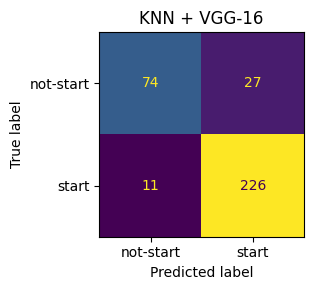

In [11]:
# L2-normalise features (good practice for cosine-like KNN)
from sklearn.preprocessing import normalize

X_tr_n = normalize(X_tr)
X_va_n = normalize(X_va)
X_te_n = normalize(X_te)

# tune k on validation set
best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_tr_n, y_tr)
    preds = knn.predict(X_va_n)
    from sklearn.metrics import f1_score
    f1 = f1_score(y_va, preds, zero_division=0)
    print(f'k={k:2d}  val-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_final.fit(np.vstack([X_tr_n, X_va_n]), np.concatenate([y_tr, y_va]))

knn_pred = knn_final.predict(X_te_n)
# KNN probability (k-NN does not give clean probabilities, use predict_proba anyway)
knn_prob = knn_final.predict_proba(X_te_n)[:, 1]

evaluate_model('KNN + VGG-16', y_te, knn_pred, knn_prob)

### 7b. XGBoost + VGG-16

scale_pos_weight = 0.42

────────────────────────────────────────────────────────────
  XGBoost + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.88      0.92      0.90       101
    start (1)       0.97      0.95      0.96       237

     accuracy                           0.94       338
    macro avg       0.92      0.93      0.93       338
 weighted avg       0.94      0.94      0.94       338

  ROC-AUC: 0.9695


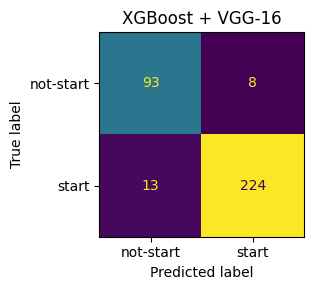

In [12]:
# class-weight balance
pos_weight = float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)
print(f'scale_pos_weight = {pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    scale_pos_weight=pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_SEED,
    early_stopping_rounds=20,
    verbosity=0,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

xgb_pred = xgb.predict(X_te)
xgb_prob = xgb.predict_proba(X_te)[:, 1]

evaluate_model('XGBoost + VGG-16', y_te, xgb_pred, xgb_prob)

### 7c. VGG-16 (fine-tuned end-to-end)

In [13]:
class PageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths  = df['img_path'].tolist()
        self.labels = df['label'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)


vgg_weights  = models.VGG16_Weights.IMAGENET1K_V1
train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

tr_df = all_labels[all_labels['split'] == 'train']
va_df = all_labels[all_labels['split'] == 'val']
te_df = all_labels[all_labels['split'] == 'test']

tr_loader = DataLoader(PageDataset(tr_df, train_tfm), batch_size=16, shuffle=True,  num_workers=0)
va_loader = DataLoader(PageDataset(va_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)
te_loader = DataLoader(PageDataset(te_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)

print(f'Train batches: {len(tr_loader)}, Val batches: {len(va_loader)}, Test batches: {len(te_loader)}')

Train batches: 108, Val batches: 12, Test batches: 11


In [14]:
def build_vgg16_classifier():
    model = models.vgg16(weights=vgg_weights)
    # freeze feature layers, fine-tune classifier
    for p in model.features.parameters():
        p.requires_grad = False
    model.classifier[6] = nn.Linear(4096, 2)
    return model.to(DEVICE)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-4, name='model'):
    pos_w = torch.tensor(
        [1.0, float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32,
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=pos_w)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_f1, best_state = -1, None
    history = []
    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, tr_loader, criterion, optimizer)
        va_loss, va_acc = eval_epoch(model, va_loader, criterion)
        _, va_pred, va_prob = predict_loader(model, va_loader)
        _, va_true, _    = predict_loader(model, va_loader)   # labels
        from sklearn.metrics import f1_score
        va_lbl = np.array(va_loader.dataset.labels)
        val_f1 = f1_score(va_lbl, va_pred, zero_division=0)
        scheduler.step()
        history.append((tr_loss, tr_acc, va_loss, va_acc, val_f1))
        print(f'Epoch {epoch:2d}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'va_loss={va_loss:.4f}  va_acc={va_acc:.4f}  val_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return history


vgg16_model = build_vgg16_classifier()
print(f'Trainable params: {sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad):,}')

Trainable params: 119,554,050


Epoch  1  tr_loss=0.4867  tr_acc=0.7816  va_loss=0.2519  va_acc=0.9210  val_f1=0.9448
Epoch  2  tr_loss=0.3149  tr_acc=0.8748  va_loss=0.3059  va_acc=0.8965  val_f1=0.9304
Epoch  3  tr_loss=0.2394  tr_acc=0.9097  va_loss=0.2753  va_acc=0.9237  val_f1=0.9480
Epoch  4  tr_loss=0.2095  tr_acc=0.9231  va_loss=0.2121  va_acc=0.9210  val_f1=0.9423
Epoch  5  tr_loss=0.2012  tr_acc=0.9272  va_loss=0.1692  va_acc=0.9510  val_f1=0.9655
Epoch  6  tr_loss=0.1202  tr_acc=0.9575  va_loss=0.1811  va_acc=0.9346  val_f1=0.9529
Epoch  7  tr_loss=0.1030  tr_acc=0.9645  va_loss=0.1959  va_acc=0.9264  val_f1=0.9465
Epoch  8  tr_loss=0.0932  tr_acc=0.9645  va_loss=0.3070  va_acc=0.9401  val_f1=0.9580
Epoch  9  tr_loss=0.0950  tr_acc=0.9656  va_loss=0.2236  va_acc=0.9401  val_f1=0.9577
Epoch 10  tr_loss=0.0818  tr_acc=0.9726  va_loss=0.2959  va_acc=0.9373  val_f1=0.9565
Epoch 11  tr_loss=0.0636  tr_acc=0.9779  va_loss=0.2454  va_acc=0.9292  val_f1=0.9492
Epoch 12  tr_loss=0.0515  tr_acc=0.9825  va_loss=0.275

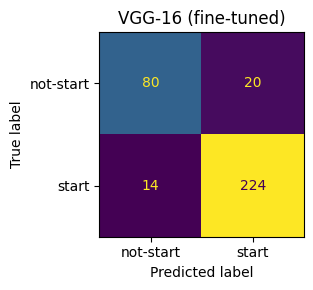

In [15]:
vgg16_history = train_model(vgg16_model, tr_loader, va_loader, n_epochs=15, lr=1e-4, name='VGG-16')

vgg16_te_lbl, vgg16_te_pred, vgg16_te_prob = predict_loader(vgg16_model, te_loader)
evaluate_model('VGG-16 (fine-tuned)', vgg16_te_lbl, vgg16_te_pred, vgg16_te_prob)

### 7d. EfficientNet-B0 (fine-tuned)

Trainable params: 4,007,734
Epoch  1  tr_loss=0.6047  tr_acc=0.7222  va_loss=0.4291  va_acc=0.8501  val_f1=0.8911
Epoch  2  tr_loss=0.4226  tr_acc=0.8492  va_loss=0.2978  va_acc=0.8856  val_f1=0.9173
Epoch  3  tr_loss=0.3117  tr_acc=0.8660  va_loss=0.2338  va_acc=0.9237  val_f1=0.9449
Epoch  4  tr_loss=0.2493  tr_acc=0.9022  va_loss=0.2104  va_acc=0.9373  val_f1=0.9552
Epoch  5  tr_loss=0.1858  tr_acc=0.9313  va_loss=0.2017  va_acc=0.9264  val_f1=0.9476
Epoch  6  tr_loss=0.1552  tr_acc=0.9499  va_loss=0.1876  va_acc=0.9264  val_f1=0.9470
Epoch  7  tr_loss=0.1328  tr_acc=0.9569  va_loss=0.2058  va_acc=0.9346  val_f1=0.9533
Epoch  8  tr_loss=0.1355  tr_acc=0.9522  va_loss=0.1909  va_acc=0.9183  val_f1=0.9412
Epoch  9  tr_loss=0.1355  tr_acc=0.9522  va_loss=0.2046  va_acc=0.9346  val_f1=0.9533
Epoch 10  tr_loss=0.1033  tr_acc=0.9645  va_loss=0.2004  va_acc=0.9264  val_f1=0.9474
Epoch 11  tr_loss=0.0968  tr_acc=0.9645  va_loss=0.2029  va_acc=0.9210  val_f1=0.9432
Epoch 12  tr_loss=0.0890  

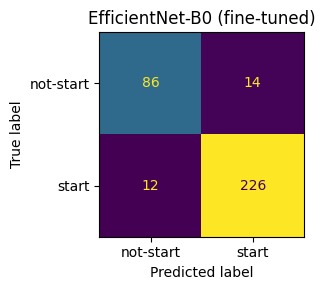

In [16]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_efficientnet():
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = efficientnet_b0(weights=weights)
    # freeze early layers
    for name, p in model.named_parameters():
        if 'features.0' in name or 'features.1' in name:
            p.requires_grad = False
    # replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 2)
    return model.to(DEVICE)


# EfficientNet uses 224×224 as well; reuse the same loaders
eff_model   = build_efficientnet()
print(f'Trainable params: {sum(p.numel() for p in eff_model.parameters() if p.requires_grad):,}')

eff_history = train_model(eff_model, tr_loader, va_loader, n_epochs=15, lr=5e-5, name='EfficientNet')

eff_te_lbl, eff_te_pred, eff_te_prob = predict_loader(eff_model, te_loader)
evaluate_model('EfficientNet-B0 (fine-tuned)', eff_te_lbl, eff_te_pred, eff_te_prob)
_, eff_te_probs_full = predict_with_probs(eff_model, te_loader)
results_probs['EfficientNet-FT'] = eff_te_probs_full


### 7e. LSTM + VGG-16

Each dossier is treated as a sequence of pages. The VGG-16 features for each page are
fed into an LSTM; the LSTM's per-step hidden state is passed through a linear head to
predict whether that page is a start page.

In [17]:
class DossierSequenceDataset(Dataset):
    """
    Each item is one dossier: (features_seq, labels_seq) where
      features_seq : (T, 4096) float32
      labels_seq   : (T,)      int64
    """
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for dossier, grp in df.groupby('dossier'):
            idx  = grp.index.tolist()
            feats = X_feat[idx]           # (T, 4096)
            lbls  = df.loc[idx, 'label'].values
            self.sequences.append(
                (torch.tensor(feats, dtype=torch.float32),
                 torch.tensor(lbls,  dtype=torch.long))
            )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def pad_collate(batch):
    feats_list, lbls_list = zip(*batch)
    lengths = torch.tensor([f.size(0) for f in feats_list])
    feats_padded = nn.utils.rnn.pad_sequence(feats_list, batch_first=True)
    lbls_padded  = nn.utils.rnn.pad_sequence(lbls_list,  batch_first=True, padding_value=-1)
    return feats_padded, lbls_padded, lengths


lstm_tr_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'train'], X_all)
lstm_va_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'val'],   X_all)
lstm_te_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'test'],  X_all)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=pad_collate)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)

print(f'Train dossiers: {len(lstm_tr_ds)}, Val: {len(lstm_va_ds)}, Test: {len(lstm_te_ds)}')

Train dossiers: 45, Val: 10, Test: 10


In [18]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.head = nn.Linear(hidden_dim * 2, 2)   # bidirectional → ×2

    def forward(self, x, lengths=None):
        x = self.proj(x)                           # (B, T, 512)
        if lengths is not None:
            x = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        out, _ = self.lstm(x)
        if lengths is not None:
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        logits = self.head(out)                    # (B, T, 2)
        return logits


def train_lstm(model, tr_loader, va_loader, n_epochs=20, lr=1e-3):
    pos_w = torch.tensor(
        [1.0, float((y_tr == 0).sum()) / max((y_tr == 1).sum(), 1)],
        dtype=torch.float32,
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=pos_w, ignore_index=-1)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    best_val_f1, best_state = -1, None
    from sklearn.metrics import f1_score

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, n = 0, 0
        for feats, lbls, lengths in tr_loader:
            feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = model(feats, lengths)          # (B, T, 2)
            B, T, C = logits.shape
            loss = criterion(logits.view(B * T, C), lbls.view(B * T))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            mask = lbls.view(B * T) != -1
            total_loss += loss.item() * mask.sum().item()
            n          += mask.sum().item()
        scheduler.step()

        # validation F1
        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for feats, lbls, lengths in va_loader:
                feats = feats.to(DEVICE)
                logits = model(feats, lengths)
                B, T, C = logits.shape
                preds = logits.argmax(-1).cpu().numpy().ravel()
                truth = lbls.numpy().ravel()
                mask  = truth != -1
                all_p.extend(preds[mask])
                all_t.extend(truth[mask])
        val_f1 = f1_score(all_t, all_p, zero_division=0)
        print(f'Epoch {epoch:2d}  loss={total_loss/max(n,1):.4f}  val_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


lstm_model = LSTMClassifier(input_dim=4096, hidden_dim=256, num_layers=2, dropout=0.3).to(DEVICE)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')

lstm_model = train_lstm(lstm_model, lstm_tr_loader, lstm_va_loader, n_epochs=20, lr=1e-3)

LSTM params: 5,252,610
Epoch  1  loss=0.6811  val_f1=0.6717
Epoch  2  loss=0.5349  val_f1=0.9242
Epoch  3  loss=0.2975  val_f1=0.9737
Epoch  4  loss=0.2421  val_f1=0.9594
Epoch  5  loss=0.1990  val_f1=0.9505
Epoch  6  loss=0.1687  val_f1=0.9655
Epoch  7  loss=0.1411  val_f1=0.9528
Epoch  8  loss=0.1092  val_f1=0.9449
Epoch  9  loss=0.1063  val_f1=0.9486
Epoch 10  loss=0.0884  val_f1=0.9465
Epoch 11  loss=0.0754  val_f1=0.9453
Epoch 12  loss=0.0578  val_f1=0.9635
Epoch 13  loss=0.0618  val_f1=0.9472
Epoch 14  loss=0.0442  val_f1=0.9516
Epoch 15  loss=0.0386  val_f1=0.9494
Epoch 16  loss=0.0390  val_f1=0.9533
Epoch 17  loss=0.0316  val_f1=0.9658
Epoch 18  loss=0.0259  val_f1=0.9492
Epoch 19  loss=0.0221  val_f1=0.9559
Epoch 20  loss=0.0224  val_f1=0.9597



────────────────────────────────────────────────────────────
  LSTM + VGG-16
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.94      0.87      0.90       100
    start (1)       0.95      0.97      0.96       238

     accuracy                           0.94       338
    macro avg       0.94      0.92      0.93       338
 weighted avg       0.94      0.94      0.94       338

  ROC-AUC: 0.9789


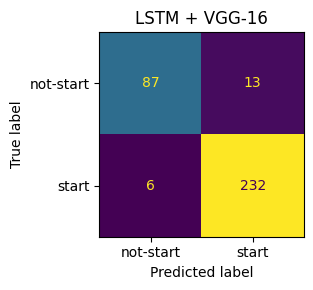

In [19]:
lstm_model.eval()
all_true_lstm, all_pred_lstm, all_prob_lstm = [], [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        feats = feats.to(DEVICE)
        logits = lstm_model(feats, lengths)        # (B, T, 2)
        probs  = torch.softmax(logits, dim=-1)[..., 1]   # (B, T)
        preds  = logits.argmax(-1)                        # (B, T)
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds.cpu().numpy()[mask].tolist())
        all_prob_lstm.extend(probs.cpu().numpy()[mask].tolist())

evaluate_model('LSTM + VGG-16', np.array(all_true_lstm),
               np.array(all_pred_lstm), np.array(all_prob_lstm))

---
## 8. Text-Only Models

### 8a. KNN-BERT


────────────────────────────────────────────────────────────
  KNN-BERT
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.84      0.82      0.83       101
    start (1)       0.92      0.93      0.93       237

     accuracy                           0.90       338
    macro avg       0.88      0.88      0.88       338
 weighted avg       0.90      0.90      0.90       338

  ROC-AUC: 0.9417


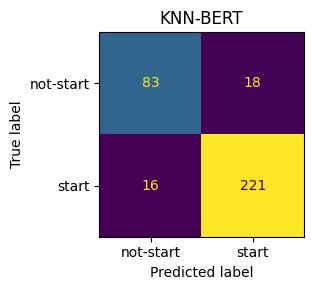

In [20]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

knn_bert = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)

pred_knn_bert_va = knn_bert.predict(X_bert_va_n)
pred_knn_bert_te = knn_bert.predict(X_bert_te_n)

evaluate_model('KNN-BERT', y_te, pred_knn_bert_te,
               y_prob=knn_bert.predict_proba(X_bert_te_n)[:, 1])


### 8b. XGBoost-BERT


────────────────────────────────────────────────────────────
  XGBoost-BERT
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.84      0.73      0.78       101
    start (1)       0.89      0.94      0.92       237

     accuracy                           0.88       338
    macro avg       0.87      0.84      0.85       338
 weighted avg       0.88      0.88      0.88       338

  ROC-AUC: 0.9346


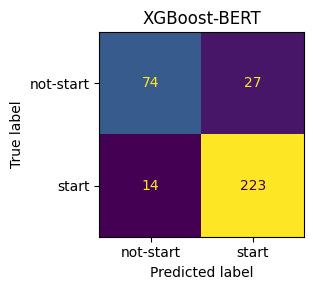

In [21]:
xgb_bert = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=20, verbosity=0,
)
xgb_bert.fit(X_bert_tr, y_tr, eval_set=[(X_bert_va, y_va)], verbose=False)

pred_xgb_bert_te = xgb_bert.predict(X_bert_te)
xgb_bert_prob    = xgb_bert.predict_proba(X_bert_te)[:, 1]

evaluate_model('XGBoost-BERT', y_te, pred_xgb_bert_te, y_prob=xgb_bert_prob)


### 8c. TEXT-CNN

1D convolutional network over BERT token embeddings (frozen BERT backbone),
with filter sizes 2 / 3 / 4 and max-over-time pooling.

TEXT-CNN trainable params: 885,890
Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.8622
  Epoch  2  val_macro_f1=0.8519
  Epoch  3  val_macro_f1=0.8767
  Epoch  4  val_macro_f1=0.8503
  Epoch  5  val_macro_f1=0.8494
  Epoch  6  val_macro_f1=0.8688
  Epoch  7  val_macro_f1=0.8794
  Epoch  8  val_macro_f1=0.9128
  Epoch  9  val_macro_f1=0.8832
  Epoch 10  val_macro_f1=0.8937
  Epoch 11  val_macro_f1=0.8762
  Epoch 12  val_macro_f1=0.8688
  Epoch 13  val_macro_f1=0.8957
  Epoch 14  val_macro_f1=0.8813
  Epoch 15  val_macro_f1=0.8791

────────────────────────────────────────────────────────────
  TEXT-CNN
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.93      0.77      0.84       101
    start (1)       0.91      0.97      0.94       237

     accuracy                           0.91       338
    macro avg       0.92      0.87      0.89       338
 weighted avg       0.92      0.91      0.91       338

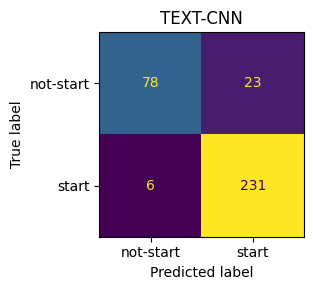

In [22]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool → linear."""
    def __init__(
        self, bert_model,
        embed_dim: int = 768,
        num_filters: int = 128,
        filter_sizes: tuple = (2, 3, 4),
        num_classes: int = NUM_CLASSES,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.bert = bert_model  # frozen
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb = out.last_hidden_state          # (B, T, E)
        x = emb.transpose(1, 2)                  # (B, E, T)
        pooled = [
            F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(ids, mask), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


tcnn_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base  = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_loader = DataLoader(TextDataset(tr_df, tcnn_tokenizer), batch_size=16,
                            shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(TextDataset(va_df, tcnn_tokenizer), batch_size=16,
                            shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(TextDataset(te_df, tcnn_tokenizer), batch_size=16,
                            shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)
trainable  = sum(p.numel() for p in tcnn_model.parameters() if p.requires_grad)
print(f'TEXT-CNN trainable params: {trainable:,}')

print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader,
                              n_epochs=15, lr=1e-3)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)
evaluate_model('TEXT-CNN', y_te, pred_tcnn_te, y_prob=probs_tcnn[:, 1])
results_probs['TEXT-CNN'] = probs_tcnn


### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,483,778
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.8566
  Epoch  2  val_macro_f1=0.9071
  Epoch  3  val_macro_f1=0.8927
  Epoch  4  val_macro_f1=0.8958
  Epoch  5  val_macro_f1=0.8843
  Epoch  6  val_macro_f1=0.9117
  Epoch  7  val_macro_f1=0.9016
  Epoch  8  val_macro_f1=0.8870
  Epoch  9  val_macro_f1=0.8961
  Epoch 10  val_macro_f1=0.8933

────────────────────────────────────────────────────────────
  BERT Fine-Tuned
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.84      0.82      0.83       101
    start (1)       0.92      0.93      0.93       237

     accuracy                           0.90       338
    macro avg       0.88      0.88      0.88       338
 weighted avg       0.90      0.90      0.90       338

  ROC-AUC: 0.9527


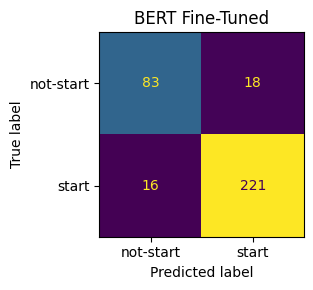

In [23]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_loader = DataLoader(TextDataset(tr_df, bert_ft_tokenizer), batch_size=8,
                               shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(TextDataset(va_df, bert_ft_tokenizer), batch_size=16,
                               shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(TextDataset(te_df, bert_ft_tokenizer), batch_size=16,
                               shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)
pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
evaluate_model('BERT Fine-Tuned', y_te, pred_bert_ft_te, y_prob=probs_bert_ft[:, 1])
results_probs['BERT-FT'] = probs_bert_ft


---
## 9. Multimodal / Fusion Models

### 9a. KNN-Ensemble (VGG16 + BERT concatenated features)

L2-normalised VGG-16 (4096-D) and BERT (768-D) features are concatenated to form a
4864-D vector, then KNN (cosine distance) is applied.


────────────────────────────────────────────────────────────
  KNN-Ensemble
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.94      0.77      0.85       101
    start (1)       0.91      0.98      0.94       237

     accuracy                           0.92       338
    macro avg       0.92      0.88      0.90       338
 weighted avg       0.92      0.92      0.91       338

  ROC-AUC: 0.9590


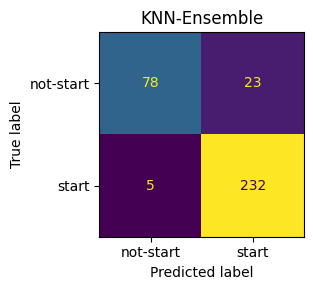

In [24]:
X_ens_tr = np.hstack([normalize(X_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_te), normalize(X_bert_te)])

knn_ens = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)

pred_knn_ens_te  = knn_ens.predict(X_ens_te)
knn_ens_prob_te  = knn_ens.predict_proba(X_ens_te)[:, 1]

evaluate_model('KNN-Ensemble', y_te, pred_knn_ens_te, y_prob=knn_ens_prob_te)


### 9b. XGBoost-Ensemble (VGG16 + BERT concatenated features)


────────────────────────────────────────────────────────────
  XGBoost-Ensemble
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.89      0.86      0.87       101
    start (1)       0.94      0.95      0.95       237

     accuracy                           0.93       338
    macro avg       0.91      0.91      0.91       338
 weighted avg       0.93      0.93      0.93       338

  ROC-AUC: 0.9726


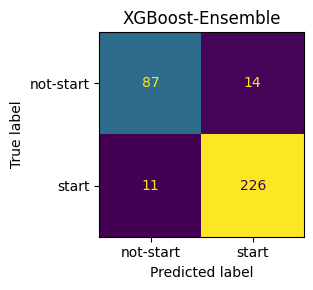

In [25]:
xgb_ens = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=20, verbosity=0,
)
xgb_ens.fit(X_ens_tr, y_tr, eval_set=[(X_ens_va, y_va)], verbose=False)

pred_xgb_ens_te = xgb_ens.predict(X_ens_te)
xgb_ens_prob_te = xgb_ens.predict_proba(X_ens_te)[:, 1]

evaluate_model('XGBoost-Ensemble', y_te, pred_xgb_ens_te, y_prob=xgb_ens_prob_te)


### 9c. Early Fusion — EfficientNet-B0 + BERT → MLP

Frozen EfficientNet-B0 (1280-D) and frozen BERT [CLS] (768-D) features are
**projected independently** then concatenated and passed through an MLP head.

  Epoch  1  val_macro_f1=0.8726
  Epoch  2  val_macro_f1=0.8777
  Epoch  3  val_macro_f1=0.9213
  Epoch  4  val_macro_f1=0.9391
  Epoch  5  val_macro_f1=0.9055
  Epoch  6  val_macro_f1=0.9274
  Epoch  7  val_macro_f1=0.9378
  Epoch  8  val_macro_f1=0.9302
  Epoch  9  val_macro_f1=0.9071
  Epoch 10  val_macro_f1=0.9433
  Epoch 11  val_macro_f1=0.9481
  Epoch 12  val_macro_f1=0.9375
  Epoch 13  val_macro_f1=0.9385
  Epoch 14  val_macro_f1=0.9313
  Epoch 15  val_macro_f1=0.9378
  Epoch 16  val_macro_f1=0.9361
  Epoch 17  val_macro_f1=0.9344
  Epoch 18  val_macro_f1=0.9344
  Epoch 19  val_macro_f1=0.9378
  Epoch 20  val_macro_f1=0.9351

────────────────────────────────────────────────────────────
  Early Fusion EfficientNet+BERT
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.84      0.81      0.82       101
    start (1)       0.92      0.93      0.93       237

     accuracy                        

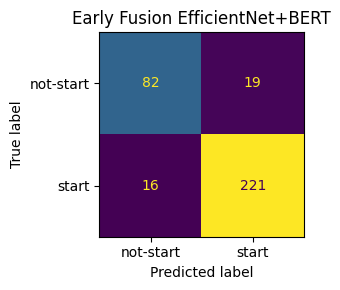

In [26]:
class EarlyFusionDataset(Dataset):
    def __init__(self, img_feats: np.ndarray, text_feats: np.ndarray,
                 labels: np.ndarray):
        self.img    = torch.tensor(img_feats,  dtype=torch.float32)
        self.text   = torch.tensor(text_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.img[i], self.text[i], self.labels[i]


class EarlyFusionClassifier(nn.Module):
    def __init__(self, img_dim=1280, text_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim,  hidden)
        self.text_proj = nn.Linear(text_dim, hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, img_feat, text_feat):
        return self.head(torch.cat([
            self.img_proj(img_feat),
            self.text_proj(text_feat),
        ], dim=1))


ef_tr_loader = DataLoader(
    EarlyFusionDataset(X_eff_tr, X_bert_tr, y_tr), batch_size=32, shuffle=True)
ef_va_loader = DataLoader(
    EarlyFusionDataset(X_eff_va, X_bert_va, y_va), batch_size=32, shuffle=False)
ef_te_loader = DataLoader(
    EarlyFusionDataset(X_eff_te, X_bert_te, y_te), batch_size=32, shuffle=False)

ef_model = EarlyFusionClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam(ef_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    ef_model.train()
    for img_f, txt_f, yb in ef_tr_loader:
        img_f, txt_f, yb = img_f.to(DEVICE), txt_f.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(img_f, txt_f), yb).backward()
        opt.step()
    sch.step()
    ef_model.eval()
    preds = []
    with torch.no_grad():
        for img_f, txt_f, _ in ef_va_loader:
            preds.extend(
                ef_model(img_f.to(DEVICE), txt_f.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)
ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for img_f, txt_f, _ in ef_te_loader:
        logits = ef_model(img_f.to(DEVICE), txt_f.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())
pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)

evaluate_model('Early Fusion EfficientNet+BERT', y_te, pred_ef_te,
               y_prob=probs_ef[:, 1])


### 9d. Late Fusion — EfficientNet-B0 FT + BERT FT (average softmax)

The softmax probability vectors from the individually trained `EfficientNet-FT` and
`BERT-FT` models are averaged to produce the final prediction.


────────────────────────────────────────────────────────────
  Late Fusion EfficientNet+BERT
────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

not-start (0)       0.89      0.84      0.86       101
    start (1)       0.93      0.95      0.94       237

     accuracy                           0.92       338
    macro avg       0.91      0.90      0.90       338
 weighted avg       0.92      0.92      0.92       338

  ROC-AUC: 0.9733


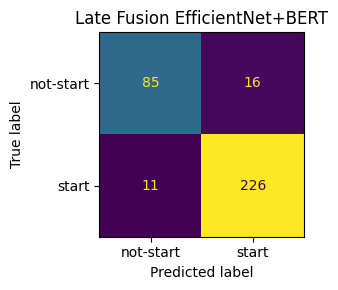

In [27]:
probs_bert_arr = results_probs['BERT-FT']          # (N_te, 2)
probs_eff_arr  = results_probs['EfficientNet-FT']  # (N_te, 2)

probs_late = (probs_bert_arr + probs_eff_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

evaluate_model('Late Fusion EfficientNet+BERT', y_te, pred_late,
               y_prob=probs_late[:, 1])


## 10. Summary

In [28]:
summary_df = pd.DataFrame(results_summary).T
summary_df = summary_df.round(4)
summary_df.index.name = 'Model'
print(summary_df.to_string())
summary_df

                                accuracy  precision  recall      f1  roc_auc
Model                                                                       
KNN + VGG-16                      0.8876     0.8933  0.9536  0.9224   0.9409
XGBoost + VGG-16                  0.9379     0.9655  0.9451  0.9552   0.9695
VGG-16 (fine-tuned)               0.8994     0.9180  0.9412  0.9295   0.9414
EfficientNet-B0 (fine-tuned)      0.9231     0.9417  0.9496  0.9456   0.9766
LSTM + VGG-16                     0.9438     0.9469  0.9748  0.9607   0.9789
KNN-BERT                          0.8994     0.9247  0.9325  0.9286   0.9417
XGBoost-BERT                      0.8787     0.8920  0.9409  0.9158   0.9346
TEXT-CNN                          0.9142     0.9094  0.9747  0.9409   0.9681
BERT Fine-Tuned                   0.8994     0.9247  0.9325  0.9286   0.9527
KNN-Ensemble                      0.9172     0.9098  0.9789  0.9431   0.9590
XGBoost-Ensemble                  0.9260     0.9417  0.9536  0.9476   0.9726

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
KNN + VGG-16,0.8876,0.8933,0.9536,0.9224,0.9409
XGBoost + VGG-16,0.9379,0.9655,0.9451,0.9552,0.9695
VGG-16 (fine-tuned),0.8994,0.9180,0.9412,0.9295,0.9414
EfficientNet-B0 (fine-tuned),0.9231,0.9417,0.9496,0.9456,0.9766
LSTM + VGG-16,0.9438,0.9469,0.9748,0.9607,0.9789
KNN-BERT,0.8994,0.9247,0.9325,0.9286,0.9417
XGBoost-BERT,0.8787,0.8920,0.9409,0.9158,0.9346
TEXT-CNN,0.9142,0.9094,0.9747,0.9409,0.9681
BERT Fine-Tuned,0.8994,0.9247,0.9325,0.9286,0.9527


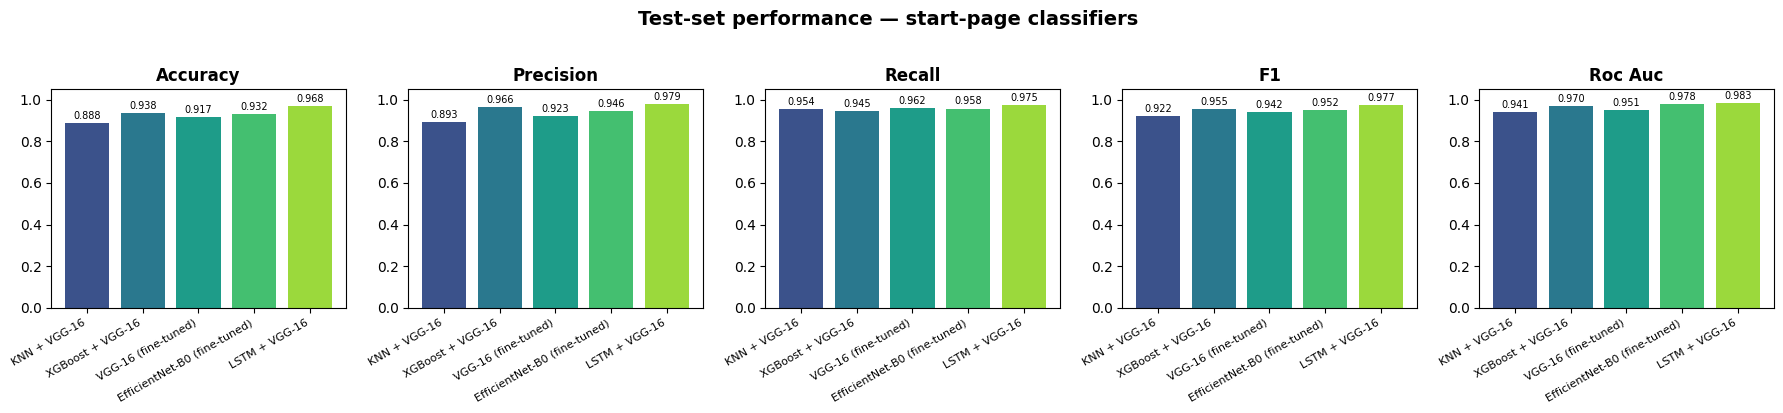

Figure saved to classifier_comparison.png


In [21]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

for ax, metric in zip(axes, metrics):
    vals   = summary_df[metric].astype(float)
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(vals)))
    bars   = ax.bar(vals.index, vals.values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Test-set performance — start-page classifiers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(WORKSPACE / 'classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to classifier_comparison.png')